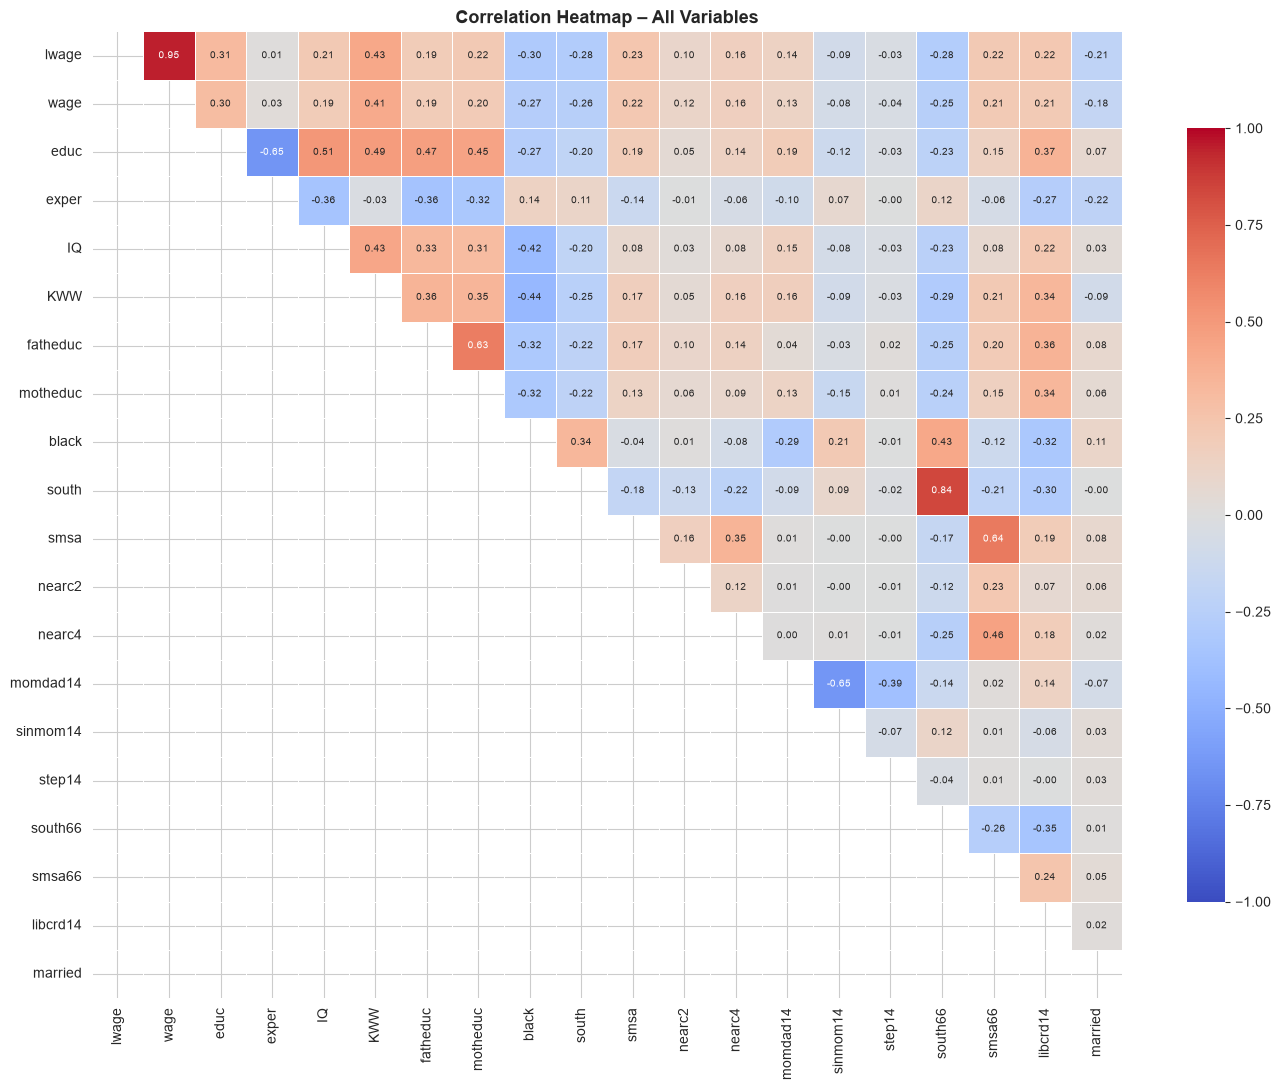

Correlation with lwage (r & p-value)


,r,p-value,Sig.
Variable,,,
wage,0.9472,0.0000,✓
KWW,0.4284,0.0000,✓
educ,0.3142,0.0000,✓
smsa,0.2346,0.0000,✓
libcrd14,0.2221,0.0000,✓
motheduc,0.2156,0.0000,✓
smsa66,0.2153,0.0000,✓
IQ,0.2129,0.0000,✓
fatheduc,0.1906,0.0000,✓


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
df = pd.read_csv("DATA/wage_eda.csv")

# Reconstruct region label
reg_cols = ["reg661","reg662","reg663","reg664","reg665","reg666","reg667","reg668","reg669"]
reg_map  = {"reg661":"New England","reg662":"Mid Atlantic","reg663":"E N Central",
            "reg664":"W N Central","reg665":"South Atlantic","reg666":"E S Central",
            "reg667":"W S Central","reg668":"Mountain","reg669":"Pacific"}
df["region"] = df[reg_cols].idxmax(axis=1).map(reg_map)

# All numeric columns for correlation (exclude expersq – redundant, exclude region dummies)
corr_vars = ["lwage", "wage", "educ", "exper", "IQ", "KWW", "fatheduc", "motheduc",
             "black", "south", "smsa", "nearc2", "nearc4",
             "momdad14", "sinmom14", "step14", "south66", "smsa66", "libcrd14", "married"]

corr = df[corr_vars].corr()

# ── 1. Full heatmap ───────────────────────────────────────────
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=~mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.4, center=0,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation Heatmap – All Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. Correlation with lwage – table with p-values ──────────
print("Correlation with lwage (r & p-value)")
rows = []
for col in corr_vars:
    if col == "lwage": continue
    d = df[["lwage", col]].dropna()
    r, p = stats.pearsonr(d["lwage"], d[col])
    rows.append({"Variable": col, "r": round(r, 4), "p-value": round(p, 4),
                 "Sig.": "✓" if p < 0.05 else "✗"})
display(pd.DataFrame(rows).sort_values("r", ascending=False).set_index("Variable"))

# ── 3. Pairplot – key continuous variables ────────────────────
pair_cols = ["lwage", "educ", "exper", "IQ", "KWW"]
sns.pairplot(df[pair_cols].dropna(), plot_kws={"alpha": 0.25, "s": 10}, diag_kind="kde")
plt.suptitle("Pairplot – Key Continuous Variables", y=1.01, fontsize=12, fontweight="bold")
plt.show()

# ── 4. Mean lwage by region ───────────────────────────────────
region_mean = df.groupby("region")["lwage"].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(region_mean.index, region_mean.values, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("Mean Log Wage")
ax.set_title("Mean Log Wage by Region", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()